# ------ Fake Instagram Profile Detection using Machine Learning--------------

#

# Initial Data Exploration and Summary Statistics

### Observations from the Output:

The dataset successfully loaded, showing a mix of numerical and categorical features relevant to fake account detection (e.g., username length, follower count, description length).

No missing values were found, indicating a clean dataset suitable for modeling.

The describe() output shows a wide range in features such as followers and follows, suggesting that the data may be highly skewed.

The dataset shape confirms that it has sufficient samples and features for building a reliable classification model.

The target variable fake shows a balanced distribution, which means the model will not be biased toward either real or fake profiles.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
path = r"C:\Users\tuhin\Downloads\Instagram_fake_profile_dataset.csv"
df = pd.read_csv(path)

display(df.head())
df.info()
print(df.isnull().sum())
display(df.describe())
df.isnull().sum()
print("Dataset shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFake vs Real Count:\n", df['fake'].value_counts())

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           5000 non-null   int64  
 1   nums/length username  5000 non-null   float64
 2   fullname words        5000 non-null   int64  
 3   nums/length fullname  5000 non-null   float64
 4   name==username        5000 non-null   int64  
 5   description length    5000 non-null   int64  
 6   external URL          5000 non-null   int64  
 7   private               5000 non-null   int64  
 8   #posts                5000 non-null   int64  
 9   #followers            5000 non-null   int64  
 10  #follows              5000 non-null   int64  
 11  fake                  5000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 468.9 KB
profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username        

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.00000
mean,0.598200,0.166175,1.212800,0.036068,0.007600,20.997200,0.049600,0.227800,103.331400,5.124435e+04,481.381800,0.50000
std,0.490311,0.194733,0.890435,0.106235,0.086855,33.234706,0.217139,0.419455,377.804886,5.963749e+05,761.530132,0.50005
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.00000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+01,58.000000,0.00000
50%,1.000000,0.089193,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,1.450000e+02,242.000000,0.50000
75%,1.000000,0.300410,2.000000,0.000000,0.000000,31.250000,0.000000,0.000000,81.000000,6.960000e+02,591.000000,1.00000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.00000


Dataset shape: (5000, 12)

Column names:
 ['profile pic', 'nums/length username', 'fullname words', 'nums/length fullname', 'name==username', 'description length', 'external URL', 'private', '#posts', '#followers', '#follows', 'fake']

Fake vs Real Count:
 fake
0    2500
1    2500
Name: count, dtype: int64


#

# Observations from the Output:

The dataset contains 2500 real accounts (0) and 2500 fake accounts (1).

The class distribution is perfectly balanced — each class represents 50% of the total dataset.

Since the data is balanced, no resampling techniques (like oversampling or undersampling) are required.

This balance ensures that the model will not be biased toward either fake or real profiles during training.

In [82]:
count = df['fake'].value_counts()
print("Fake vs Real account count:")
print(count)
print("\nPercentage distribution:")
print((count / len(df)) * 100)


Fake vs Real account count:
fake
0    2500
1    2500
Name: count, dtype: int64

Percentage distribution:
fake
0    50.0
1    50.0
Name: count, dtype: float64


#

## Importance of features acording to the correlation heatmap

| Feature              | Correlation with 'fake' | Importance for Prediction                         |
| -------------------- | ----------------------- | ------------------------------------------------- |
| profile pic          | -0.78                   | Very important (missing profile pic signals fake) |
| nums/length username | 0.66                    | Very important (more numbers in username in fake) |
| description length   | -0.51                   | Important (shorter description in fake)           |
| fullname words       | -0.30                   | Moderate importance                               |
| nums/length fullname | 0.29                    | Moderate importance                               |
| #posts               | -0.25                   | Moderate importance                               |
| #follows             | -0.24                   | Moderate importance                               |
| external URL         | -0.23                   | Moderate importance                               |

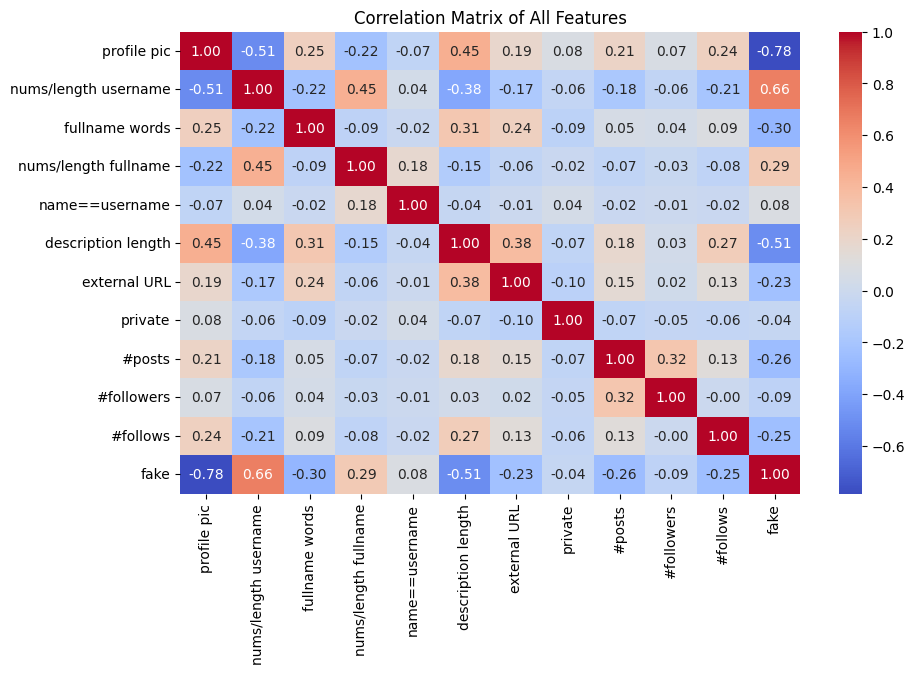

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of All Features")
plt.show()

#

# Fake vs Real (Boxplots)

## Key_Findings 

* Real accounts almost always have a profile picture, while fake accounts mostly lack one.

* Fake accounts tend to use usernames with more numerical content relative to their length.

* Real accounts generally have longer profile descriptions, whereas fake accounts' descriptions are often short or missing.

* The full name in real accounts typically contains more words; fake accounts use shorter names.

* Fake accounts usually have fewer posts compared to real accounts.

* Fake accounts follow fewer users than real accounts, reflecting lower engagement and activity.

C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\3572583061.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fake', y=feature, data=df, palette='coolwarm')
C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\3572583061.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fake', y=feature, data=df, palette='coolwarm')
C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\3572583061.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fake', y=feature, data=df, palette='coolwarm')
C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\35725830

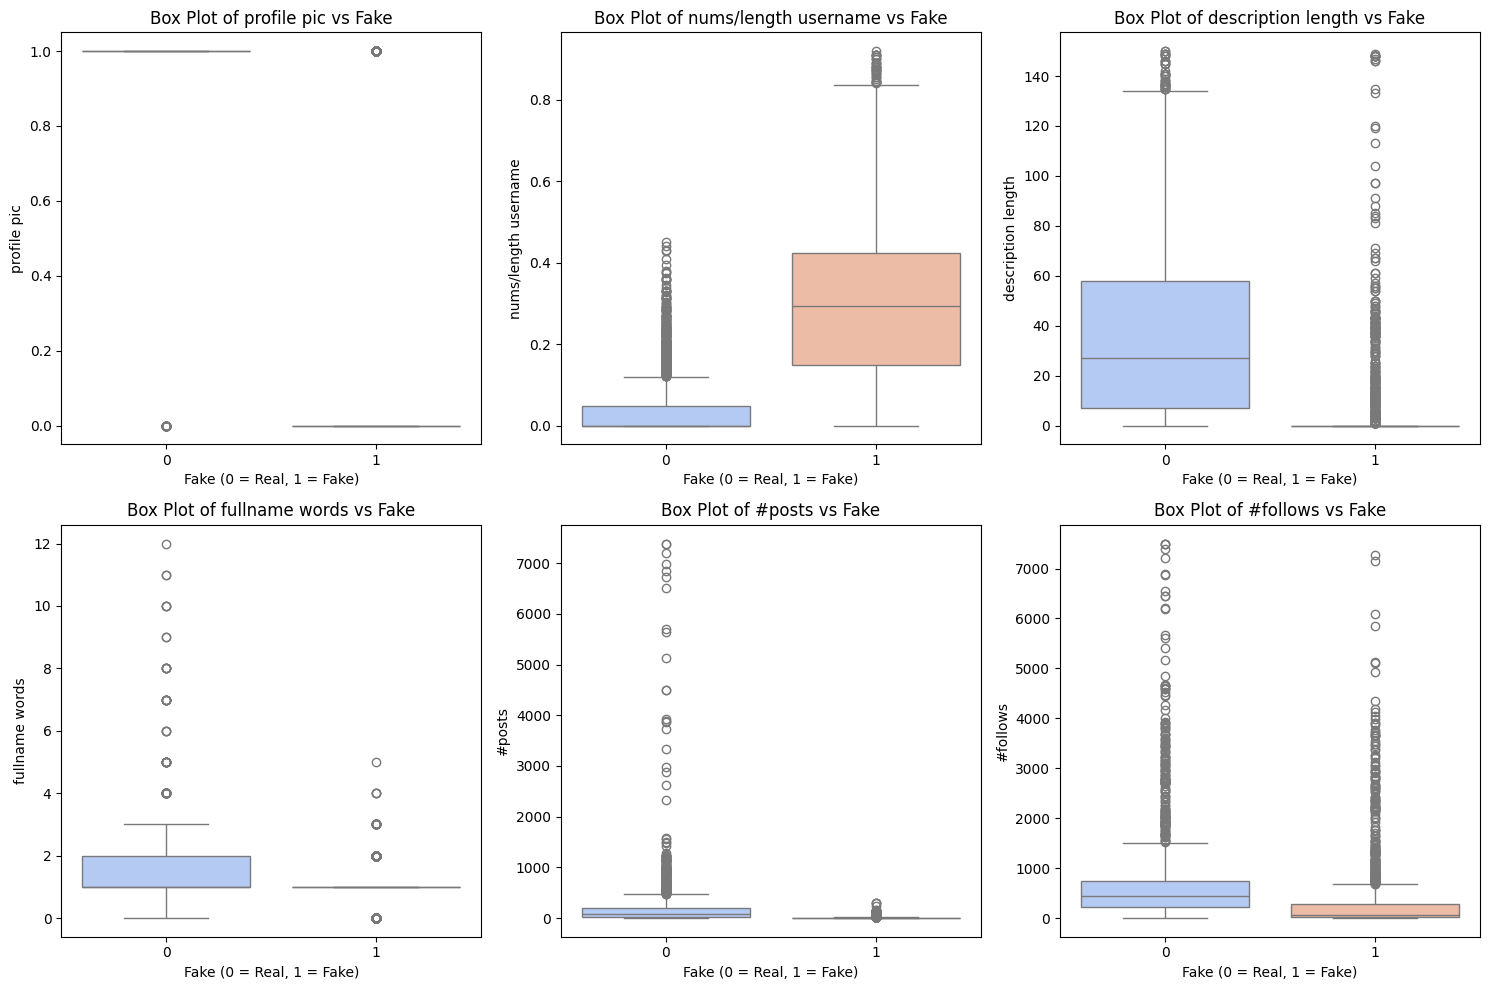

In [52]:
df = pd.read_csv(r"C:\Users\tuhin\Downloads\Instagram_fake_profile_dataset.csv")

selected_features = ['profile pic', 'nums/length username', 'description length',
                     'fullname words', '#posts', '#follows', 'fake']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features[:-1], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='fake', y=feature, data=df, palette='coolwarm')
    plt.title(f'Box Plot of {feature} vs Fake')
    plt.xlabel('Fake (0 = Real, 1 = Fake)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

### Statistical Comparison (mean differences)

In [48]:
print("\nAverage values for each feature by class:\n")
df.groupby('fake').mean()


Average values for each feature by class:



,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows
fake,,,,,,,,,,,
0,0.9828,0.036900,1.4824,0.005048,0.0004,37.9860,0.0992,0.2440,199.8364,102392.518,668.4072
1,0.2136,0.295449,0.9432,0.067089,0.0148,4.0084,0.0000,0.2116,6.8264,96.186,294.3564


## keping only important features to reduce noise

In [56]:
import pandas as pd

df = pd.read_csv(r"C:\Users\tuhin\Downloads\Instagram_fake_profile_dataset.csv")

selected_features = ['profile pic', 'nums/length username', 'description length',
                     'fullname words', '#posts', '#follows', 'fake']

clean_df = df[selected_features]

print("Shape:", clean_df.shape)
display(clean_df.head())


Shape: (5000, 7)


,profile pic,nums/length username,description length,fullname words,#posts,#follows,fake
0,1,0.27,53,0,32,955,0
1,1,0.00,44,2,286,533,0
2,1,0.10,0,2,13,98,0
3,1,0.00,82,1,679,651,0
4,1,0.00,0,2,6,126,0


# Feature Engineering and Dataset Shape
### Newly Created Features:

1. followers_following_ratio → Measures user influence; higher ratio indicates more followers compared to following.

2. posts_per_follower → Represents content activity relative to followers.

3. activity_score → A weighted metric combining posts, followers, and follows to estimate overall engagement.

4. description_density → Reflects how descriptive the user’s profile is relative to their name length.

In [58]:
selected_features = ['profile pic', 'nums/length username', 'description length',
                     'fullname words', '#posts', '#followers', '#follows', 'fake']

df_cleaned = df[selected_features]

df_cleaned['followers_following_ratio'] = (df['#followers'] + 1) / (df['#follows'] + 1)
df_cleaned['posts_per_follower'] = (df['#posts'] + 1) / (df['#followers'] + 1)
df_cleaned['activity_score'] = (df['#posts'] * 0.5) + (df['#followers'] * 0.3) + (df['#follows'] * 0.2)
df_cleaned['description_density'] = (df['description length'] + 1) / (df['fullname words'] + 1)

print("Shape:", df_cleaned.shape)

Shape: (5000, 12)


C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\1163251719.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['followers_following_ratio'] = (df['#followers'] + 1) / (df['#follows'] + 1)
C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\1163251719.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['posts_per_follower'] = (df['#posts'] + 1) / (df['#followers'] + 1)
C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\1163251719.py:8: SettingWithCopyWarning: 
A value is trying to be set

In [61]:
df_cleaned.head()

,profile pic,nums/length username,description length,fullname words,#posts,#followers,#follows,fake,followers_following_ratio,posts_per_follower,activity_score,description_density
0,1,0.27,53,0,32,1000,955,0,1.047071,0.032967,507.0,54.000000
1,1,0.00,44,2,286,2740,533,0,5.132959,0.104706,1071.6,15.000000
2,1,0.10,0,2,13,159,98,0,1.616162,0.087500,73.8,0.333333
3,1,0.00,82,1,679,414,651,0,0.636503,1.638554,593.9,41.500000
4,1,0.00,0,2,6,151,126,0,1.196850,0.046053,73.5,0.333333


#

### **Feature Importance Analysis Using Random Forest Classifier**

This code uses a **Random Forest Classifier** to identify which features contribute most to predicting whether an Instagram profile is *real* or *fake*.
By training the model on the dataset and calculating the **feature importance scores**, we can determine the relative influence of each variable on the model’s decision-making process.
The output helps in **feature selection**, allowing us to retain only the most impactful features for further modeling.

---


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = df_cleaned.drop(columns=['fake'])
y = df_cleaned['fake']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)


                      Feature  Importance
0                 profile pic    0.227671
4                      #posts    0.154298
5                  #followers    0.132213
1        nums/length username    0.116102
2          description length    0.091639
7   followers_following_ratio    0.088783
9              activity_score    0.072458
10        description_density    0.067415
6                    #follows    0.025393
8          posts_per_follower    0.016459
3              fullname words    0.007568


C:\Users\tuhin\AppData\Local\Temp\ipykernel_21288\1696489942.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


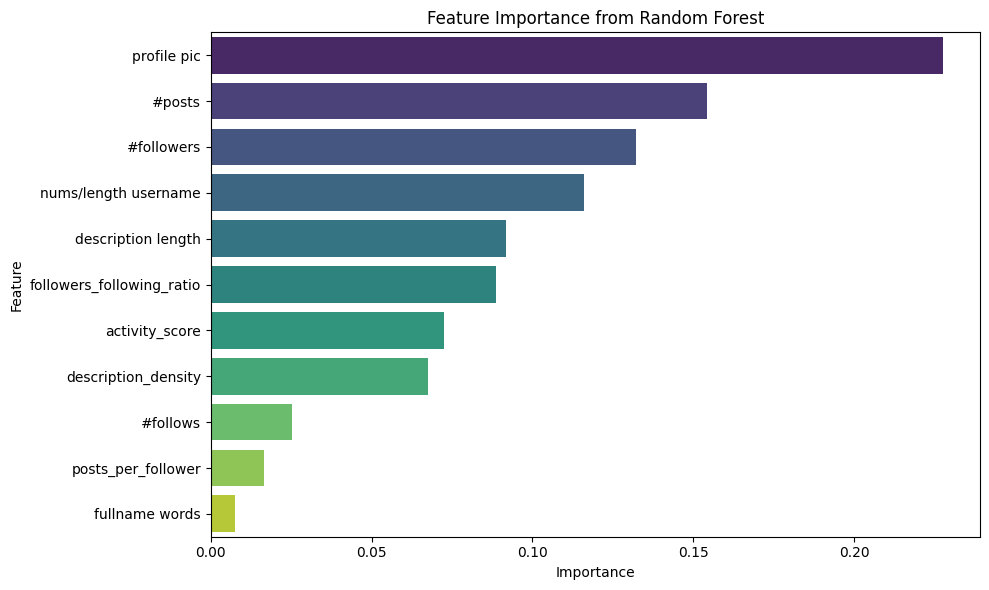

In [66]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Feature Importance from Random Forest")
plt.tight_layout()
plt.show()


## Creating the final dataframe by removing less important features

In [67]:
df_final = df_cleaned.drop(columns=['#follows', 'posts_per_follower', 'fullname words'])
print("Shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())

Shape: (5000, 9)
Columns: ['profile pic', 'nums/length username', 'description length', '#posts', '#followers', 'fake', 'followers_following_ratio', 'activity_score', 'description_density']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## Feature Scaling Using StandardScaler for Model Preparation

In [71]:
from sklearn.preprocessing import StandardScaler


X = df_final.drop('fake', axis=1)
y = df_final['fake']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_final = pd.concat([df_scaled, y.reset_index(drop=True)], axis=1)

print("Scaled df_final shape:", df_final.shape)
display(df_final.head())

Scaled df_final shape: (5000, 9)


,profile pic,nums/length username,description length,#posts,#followers,followers_following_ratio,activity_score,description_density,fake
0,0.819562,0.533220,0.963029,-0.188824,-0.084258,-0.045077,-0.083899,2.662594,0
1,0.819562,-0.853433,0.692201,0.483548,-0.081340,-0.044937,-0.080744,0.301274,0
2,0.819562,-0.339858,-0.631849,-0.239119,-0.085668,-0.045058,-0.086320,-0.586744,0
3,0.819562,-0.853433,1.835699,1.523872,-0.085241,-0.045091,-0.083414,1.905760,0
4,0.819562,-0.853433,-0.631849,-0.257649,-0.085682,-0.045072,-0.086322,-0.586744,0


# Performance Evaluation of Isolation Forest for Fake Profile Detection

According to the project guidelines, the Isolation Forest model was required to be used. However, the model’s accuracy score was found to be quite low, indicating that it may not be well-suited for this particular dataset.

In [72]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [87]:
x = df_final.drop('fake', axis=1)
y = df_final['fake']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

iso = IsolationForest(contamination=0.5, random_state=42)
iso.fit(X_train)
y_pred_iso = iso.predict(X_test)
y_pred_iso = [1 if i == -1 else 0 for i in y_pred_iso]

accuracy = round(accuracy_score(y_test, y_pred_iso), 3)
print("Isolation Forest Accuracy:", accuracy)

Isolation Forest Accuracy: 0.503


## Evaluating a model trained using Gradient Boosting

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = df_final.drop('fake', axis=1)
y = df_final['fake']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))

Accuracy: 0.978
Precision: 0.99
Recall: 0.966
F1 Score: 0.978


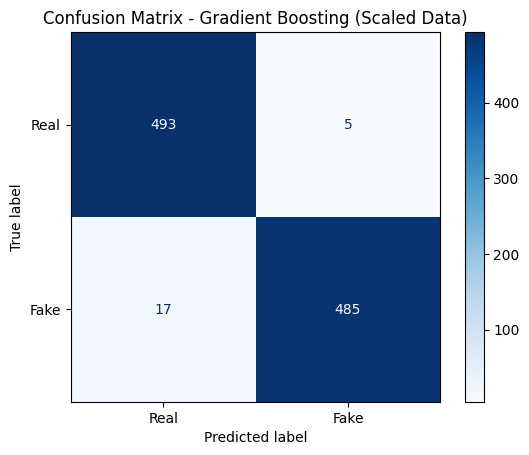

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Gradient Boosting (Scaled Data)")
plt.show()


### Training vs Testing Accuracy Comparison
Since the training and testing accuracies are nearly equal, the model appears to be well-generalized without signs of overfitting

In [95]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", round(train_acc, 3))
print("Testing Accuracy:", round(test_acc, 3))

Training Accuracy: 0.994
Testing Accuracy: 0.978


#

## Feature Importance Visualization

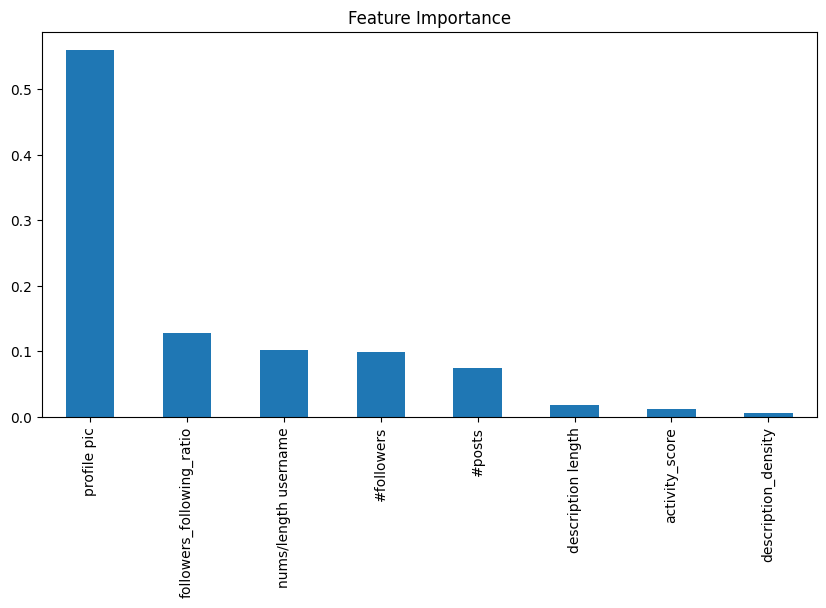

In [100]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()


#

### Interpretation of the ROC Curve - Gradient Boosting Classifier

The ROC (Receiver Operating Characteristic) curve measures how well the model distinguishes between real and fake accounts.

The true positive rate (correctly identified fakes) is plotted against the false positive rate (real accounts wrongly flagged as fake).

The blue curve’s position near the top-left shows excellent model performance.

The area under the curve (AUC) is 0.996, meaning the model is almost perfect at identifying fakes versus real accounts.

The red dashed line is the baseline for random guessing—your model performs much better than this.

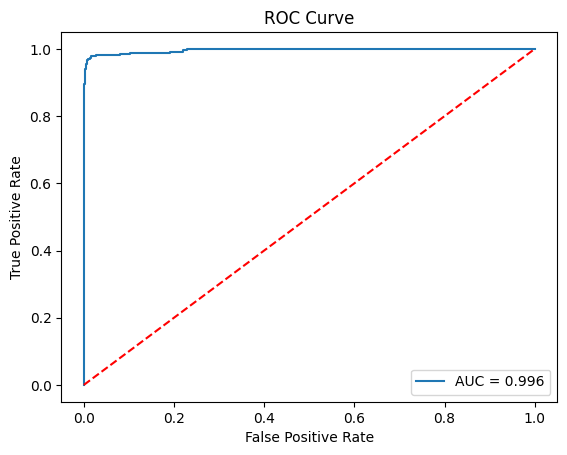

In [98]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'r--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


#

# -----------------------------------THANK YOU---------------------------------